In [1]:
#!/usr3/graduate/jtszhu/.conda/envs/TA2_jtz/bin/python3
# coding: utf-8

from pandas import read_csv
from pandas import DataFrame
from pandas import Grouper
from matplotlib import pyplot
import scipy

from scipy import stats
import json
import numpy as np
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import seaborn as sns

from scipy.stats import norm
from scipy.stats import ttest_rel
from scipy.stats import ttest_1samp
from scipy.stats import ttest_ind
import pingouin as pg
from tqdm import tqdm

from joblib import Parallel, delayed

import matplotlib as mpl

import random

import psutil

import os
os.environ["OMP_WAIT_POLICY"] = "active"

import graph_tool.all as gt
gt.openmp_enabled()

import scipy.sparse
import scipy.sparse.csgraph


dir_dict = {'sessionDir': [
    "R0817_20181120",
    "R0817_20190625",
    "R1187_20181119", "R1187_20190703",
    "R0959_20181128", "R0959_20190703",
    "R1373_20181128", "R1373_20190708",
    "R0983_20190722",
    "R0983_20190723",
    "R1507_20190621", "R1507_20190627",
    "R0898_20190723",
    "R0898_20190724",
    "R1452_20181119", "R1452_20190711",
    "R1547_20190729", "R1547_20190730",
    "R1103_20181121",
    "R1103_20190710"
],
    'bietfpDir': [
        "R0817_TA2_11.20.18",
        "R0817_TA2_6.25.19",
        "R1187_TA2_11.19.18", "R1187_TA2_7.3.19",
        "R0959_TA2_11.28.18", "R0959_TA2_7.3.19",
        "R1373_TA2_11.28.18", "R1373_TA2_7.8.19",
        "R0983_TA2_7.22.19",
        "R0983_TA2_7.23.19",
        "R1507_TA2_6.21.19", "R1507_TA2_6.27.19",
        "R0898_TA2_7.23.19",
        "R0898_TA2_7.24.19",
        "R1452_TA2_11.19.18", "R1452_TA2_7.11.19",
        "R1547_TA2_7.29.19", "R1547_TA2_7.30.19",
        "R1103_TA2_11.21.18",
        "R1103_TA2_7.10.19"

    ],
}
aparc_list_in_lobe_order = ['lateraloccipital', 'lingual', 'cuneus', 'pericalcarine',
                            'superiorparietal', 'inferiorparietal', 'supramarginal', 'postcentral', 'precuneus',
                    'isthmuscingulate', 'posteriorcingulate',
                                                'superiortemporal', 'middletemporal', 'inferiortemporal', 'bankssts', 'fusiform',
              'transversetemporal', 'entorhinal', 'temporalpole', 'parahippocampal',
              'superiorfrontal', 'rostralmiddlefrontal', 'caudalmiddlefrontal', 'parstriangularis',
                    'parsopercularis', 'parsorbitalis', 'lateralorbitofrontal', 'medialorbitofrontal',
              'precentral', 'paracentral', 'frontalpole','rostralanteriorcingulate', 'caudalanteriorcingulate',

                            'insula'
              ]

aparc_hh_list = list()
for roi_str in aparc_list_in_lobe_order:
    aparc_hh_list.append(roi_str + '_lh')
    aparc_hh_list.append(roi_str + '_rh')

occipital_rois = ['lateraloccipital', 'lingual', 'cuneus', 'pericalcarine']
parietal_rois = ['superiorparietal', 'inferiorparietal', 'supramarginal', 'postcentral', 'precuneus']
temporal_rois = ['superiortemporal', 'middletemporal', 'inferiortemporal', 'bankssts', 'fusiform',
              'transversetemporal', 'entorhinal', 'temporalpole', 'parahippocampal']
frontal_rois = [ 'superiorfrontal', 'rostralmiddlefrontal', 'caudalmiddlefrontal', 'parstriangularis',
                    'parsopercularis', 'parsorbitalis', 'lateralorbitofrontal', 'medialorbitofrontal',
              'precentral', 'paracentral', 'frontalpole']
cingulate_rois = ['isthmuscingulate', 'posteriorcingulate','rostralanteriorcingulate', 'caudalanteriorcingulate']
insula_roi = ['insula']

frontal_precentral =  ['precentral', 'paracentral']
frontal_rostralmiddle = ['superiorfrontal', 'rostralmiddlefrontal', 'caudalmiddlefrontal', 'parstriangularis','parsopercularis']
frontal_lateralorbito = ['parsorbitalis', 'lateralorbitofrontal', 'medialorbitofrontal', 'frontalpole']


def get_lobe_idxs(rois, hemi='lh'):
    rois_idxs = list()
    for item in rois:
        print(item)
        rois_idxs.append(int(np.where(np.array(aparc_hh_list) == item+'_'+hemi)[0]))
    print(rois_idxs)
    return rois_idxs


occipital_left_idxs = get_lobe_idxs(occipital_rois, hemi='lh')
occipital_right_idxs = get_lobe_idxs(occipital_rois, hemi='rh')
temporal_left_idxs = get_lobe_idxs(temporal_rois, hemi='lh')
temporal_right_idxs = get_lobe_idxs(temporal_rois, hemi='rh')
parietal_left_idxs = get_lobe_idxs(parietal_rois, hemi='lh')
parietal_right_idxs = get_lobe_idxs(parietal_rois, hemi='rh')
frontal_left_idxs = get_lobe_idxs(frontal_rois, hemi='lh')
frontal_right_idxs = get_lobe_idxs(frontal_rois, hemi='rh')
cingulate_left_idxs = get_lobe_idxs(cingulate_rois, hemi='lh')
cingulate_right_idxs = get_lobe_idxs(cingulate_rois, hemi='rh')
insula_left_idxs = get_lobe_idxs(insula_roi, hemi='lh')
insula_right_idxs = get_lobe_idxs(insula_roi, hemi='rh')
frontal_precentral_lh_idxs = get_lobe_idxs(frontal_precentral, hemi='lh')
frontal_rostralmiddle_lh_idxs = get_lobe_idxs(frontal_rostralmiddle, hemi='lh')
frontal_lateralorbito_lh_idxs = get_lobe_idxs(frontal_lateralorbito, hemi='lh')
frontal_precentral_rh_idxs = get_lobe_idxs(frontal_precentral, hemi='rh')
frontal_rostralmiddle_rh_idxs = get_lobe_idxs(frontal_rostralmiddle, hemi='rh')
frontal_lateralorbito_rh_idxs = get_lobe_idxs(frontal_lateralorbito, hemi='rh')

code_path = '/usr3/graduate/jtszhu/TA2/Decoding/'
import sys

this_folder = '/usr3/graduate/jtszhu/TA2'
sys.path.append(this_folder)

import Decoding.PlotAllStats as pas

stype = 's1'

from LoadData_TANoise import Data as DataNoise
from LoadData import Data as Data

import PlotFigures as pf
import Settings as pltSet

data_exp = 'TA2'
sessionDir_list = dir_dict['sessionDir']
sessionDir = dir_dict['sessionDir'][0]
bietfpDir = dir_dict['bietfpDir'][0]

data = None
if data_exp == 'noise':
    data = DataNoise(sessionDir, bietfpDir, load_meg=False)
else:
    data = Data(sessionDir, bietfpDir, load_meg=False)

time_ahead = data.time_ahead

pstart = -500
avg_timestep = 5


# get decoding results from data path
def get_res(dir_dict, para_set, stype, data_path, code_path, precue='T1'):
    if precue == 'T1':
        not_precue = 'T2'
    elif precue == 'T2':
        not_precue = 'T1'
    os.chdir(data_path)
    print('data_path', data_path)

    json_file_path = os.path.join(code_path, 'sourcedecoding_env.json')
    with open(json_file_path, 'r') as j:
        para_j = json.loads(j.read())

    if para_set[:12] == 'TA2_aparcr10':
        para_dict = para_j['TA2_aparcr10']
        dtype = para_set[13:]
    if para_set[:13] == 'TA2_aparcr100':
        para_dict = para_j['TA2_aparcr100']
        dtype = para_set[14:]
    elif para_set[:15] == 'TA2_aparctopr10':
        para_dict = para_j['TA2_aparctopr10']
        dtype = para_set[16:] + '_top33'
    else:
        para_dict = para_j[para_set]
        dtype = para_dict['dtype']

    print('dtype:', dtype)

    data_exp = para_dict['data_exp']
    avg_timestep = para_dict['avg_timestep']
    fold_k = para_dict['fold_k']
    nReps = para_dict['nReps']
    avg_trial = para_dict['avg_trial']
    topN = para_dict['topN']

    decode_by_sensors = para_dict['decode_by_sensors']
    ico_size = para_dict['ico_size']
    label = para_dict['label']

    sessionDir_list = dir_dict['sessionDir']
    sessionDir = dir_dict['sessionDir'][0]
    bietfpDir = dir_dict['bietfpDir'][0]

    para_str = "avg%sf%st%sCh%snReps%s%s%s.npy" % (avg_timestep, fold_k,
                                                   avg_trial, topN, nReps, dtype, stype)
    plot_para_str = "avg %s, %s fold, avg %s trials, Ch %s, %s rep, %s, session %s " % \
                    (avg_timestep, fold_k, avg_trial, topN, nReps, dtype, stype)

    this_score_list_arr_this_precue = pf.load_score_arr(
        "score_list_precue%s_%s_" % (precue, precue) + para_str[:-4], sessionDir_list, is_avg=False)
    this_score_list_arr_not_this_precue = pf.load_score_arr(
        "score_list_precue%s_%s_" % (not_precue, precue) + para_str[:-4], sessionDir_list, is_avg=False)

    this_score_list_arr_this_precue = np.mean(np.mean(this_score_list_arr_this_precue, axis=3), axis=1)
    this_score_list_arr_not_this_precue = np.mean(np.mean(this_score_list_arr_not_this_precue, axis=3), axis=1)

    return this_score_list_arr_this_precue, this_score_list_arr_not_this_precue


####################
# Load T1 decoding data
#####################
at_list = list()
uat_list = list()
for region in aparc_hh_list:
    print('region:', region)
    fig_path = os.path.join('/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/68regions_r100/', region,
                            'figures')
    dir = os.listdir(fig_path)

    para_set = 'TA2_aparcr100_' + region
    data_path = '/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/68regions_r100/%s/res' % region

    attend_acc, unattend_acc = get_res(dir_dict, para_set, stype, data_path, code_path)
    at_list.append(attend_acc)
    uat_list.append(unattend_acc)
T1at_arr = np.array(at_list)
T1uat_arr = np.array(uat_list)

####################
# Load T2 decoding data
#####################

at_list = list()
uat_list = list()
for region in aparc_hh_list:
    print('region:', region)
    fig_path = os.path.join('/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/68regions_r100/', region,
                            'figures')
    dir = os.listdir(fig_path)

    para_set = 'TA2_aparcr100_' + region
    data_path = '/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/68regions_r100/%s/res' % region

    attend_acc, unattend_acc = get_res(dir_dict, para_set, stype, data_path, code_path, precue='T2')
    at_list.append(attend_acc)
    uat_list.append(unattend_acc)
T2at_arr = np.array(at_list)
T2uat_arr = np.array(uat_list)


lobe_name_list = ['occipital_lh', 'occipital_rh', 'parietal_lh', 'parietal_rh',
                  'temporal_lh', 'temporal_rh', 'frontal_lh', 'frontal_rh',
                  'cingulate_lh', 'cingulate_rh', 'insula_lh', 'insula_rh'
                  ]

x_array = np.array(
    range(data.time_window_T1_tmp[0] + pstart, data.time_window_af_cueT_tmp[0] + pstart - avg_timestep - 10 * 5,
          avg_timestep))

lobe_idxs_list = [occipital_left_idxs, occipital_right_idxs, parietal_left_idxs, parietal_right_idxs,
                  temporal_left_idxs, temporal_right_idxs, frontal_left_idxs, frontal_right_idxs,
                  cingulate_left_idxs, cingulate_right_idxs, insula_left_idxs, insula_right_idxs
                  ]

def avg_sessions_for_subjects(y1, y2):
    new_y1 = []
    new_y2 = []
    for i in range(0, len(y1),2):
        new_y1.append((y1[i]+y1[i+1])/2)
        new_y2.append((y2[i]+y2[i+1])/2)
    return np.array(new_y1), np.array(new_y2)


def get_net_centrality_func(t, input_arr, aparc_list, operation='mean', stride=5, ed_t=59, st_t=10, win=10, resolt=1):
    # for t in range(st_t, ed_t, stride):
    # print('time', int(t*5/resolt)-50, 'ms')
    input_m = np.mean(input_arr[:, :, t:t + win], axis=1)
    # print(at_m)
    corr_at_dis_matrix = 1 - np.abs(np.corrcoef(input_m))

    # Number of variables
    num_variables = corr_at_dis_matrix.shape[0]

    # Create an empty graph
    g = gt.Graph(directed=False)
    eweight = g.new_ep("double")

    # Add vertices (nodes)
    g.add_vertex(num_variables)

    # Add edges with weights (correlations)
    for i in range(num_variables):
        for j in range(i, num_variables):
            weight = corr_at_dis_matrix[i, j]
            e = g.add_edge(i, j)
            eweight[e] = weight

    with gt.openmp_context(nthreads=68, schedule="guided"):
        closeness_centrality = gt.closeness(g, weight=eweight)

    rois_centrality = list(closeness_centrality.get_array())  # 'weight'

    if operation == 'mean':
        this_avg_op = np.mean(input_arr[:, :, t:t + win], axis=2)
    elif operation == 'max':
        this_avg_op = np.max(input_arr[:, :, t:t + win], axis=2)
    elif operation == 'time':
        this_avg_op = input_arr[:, :, t]
    rois_avg_acc = (np.mean(this_avg_op, axis=1))  # avearge sessions

    del g

    return rois_centrality, rois_avg_acc


def get_centrality_list(input_arr, aparc_list, operation='mean', stride=5, ed_t=59, st_t=10, win=10, resolt=1):
    rois_avg_acc_list = list()
    rois_centrality_list = list()
    # print('hi')
    #     res = Parallel(n_jobs=10)(delayed(get_net_centrality_func)(t,input_arr,aparc_list, operation,stride, ed_t,st_t, win,resolt) for t in range(st_t, ed_t, stride))
    #     # res = get_net_centrality_func(0,input_arr,aparc_list, operation,stride, ed_t,st_t, win,resolt)
    #     for item in res:
    #         rois_centrality_list.append(item[0])
    #         rois_avg_acc_list.append(item[1])

    for t in range(st_t, ed_t, stride):
        res = get_net_centrality_func(t, input_arr, aparc_list, operation, stride, ed_t, st_t, win, resolt)

        rois_centrality_list.append(res[0])
        rois_avg_acc_list.append(res[1])  # avearge sessions
    return rois_centrality_list, rois_avg_acc_list


def get_group_property(y1_arr, y2_arr, net_type='corrsum', is_by_rois=False,
                       rois_idxs=None):  # correlation sum /  closeness centrality
    # input shape: sess * time * rois
    # return variable size: # rois * time step
    # functional connectivity (correlation matrix) based on decoding accuracy
    stride = 1
    y1_arr = y1_arr.transpose(2, 0, 1)  # rois * sess * time
    y2_arr = y2_arr.transpose(2, 0, 1)

    y1_group_corr_list = get_group_corr_list(np.sum(y1_arr, axis=1), aparc_hh_list, stride=stride, st_t=0,
                                             ed_t=259 - 10)
    y2_group_corr_list = get_group_corr_list(np.sum(y2_arr, axis=1), aparc_hh_list, stride=stride, st_t=0,
                                             ed_t=259 - 10)

    if net_type == 'corrsum':
        y1_group_prop, y2_group_prop = get_corrsum(y1_group_corr_list, y2_group_corr_list)
        if is_by_rois:
            y1_group_prop, y2_group_prop = y1_group_prop[rois_idxs, :], y2_group_prop[rois_idxs, :]

    elif net_type == 'closeness':
        y1_group_closeness_list, _ = get_centrality_list(y1_arr, aparc_hh_list, stride=stride, st_t=0, ed_t=259 - 10)
        y2_group_closeness_list, _ = get_centrality_list(y2_arr, aparc_hh_list, stride=stride, st_t=0, ed_t=259 - 10)

        y1_group_prop = np.array(y1_group_closeness_list).transpose()
        y2_group_prop = np.array(y2_group_closeness_list).transpose()

        if is_by_rois:
            y1_group_prop, y2_group_prop = y1_group_prop[rois_idxs, :], y2_group_prop[rois_idxs, :]

        del y1_group_closeness_list, y2_group_closeness_list
    # print(np.shape(y1_group_prop))

    return y1_group_prop, y2_group_prop


def get_bin_arr(n):
    bin_list = []
    for i in range(0, 2 ** n):
        b = bin(i)[2:]
        bin_list.append(list(str(b).zfill(n)))
    bin_arr = np.array(bin_list)
    return bin_arr


def get_clusters(input_arr, threshold):
    first_idx = 0
    last_idx = 0
    this_sum = 0
    cluster_list = []
    for i in range(len(input_arr)):

        if input_arr[i] > np.abs(threshold):
            if i - 1 != last_idx:
                cluster_list.append((this_sum, first_idx, last_idx))
                first_idx = i
                this_sum = 0

            last_idx = i
            this_sum += np.abs(input_arr[i])
        if i == len(input_arr) - 1:  # last one
            cluster_list.append((this_sum, first_idx, last_idx))

    return cluster_list


def sort_clusters(cluster_list):
    cluster_list.sort(reverse=True)
    return cluster_list


def get_pv_list(s_list, mc_s_array, thres, order, mc_size):
    # print(np.shape(s_list))
    # obs_s, st_idx, ed_idx = get_max_cluster_value(s_list, thres)
    ranked_clusters = sort_clusters(get_clusters(s_list, thres))
    print(ranked_clusters)
    obs_s, st_idx, ed_idx = ranked_clusters[order]
    print(obs_s, st_idx, ed_idx)

    pv_list = []
    random_s = []
    for i in range(np.shape(mc_s_array)[0]):
        # this_random_s = get_max_cluster_value(mc_s_array[i, :], thres)
        ranked_clusters = sort_clusters(get_clusters(mc_s_array[i, :], thres))
        if len(ranked_clusters) < order + 1:
            random_s.append(0)
        else:
            this_random_s = ranked_clusters[order]
            # this_random_s = np.sum(mc_s_array[i,st_idx:ed_idx+1])
            # plot a distribution, put the obesrved along the x axis
            # find the max cluster

            random_s.append(this_random_s[0])

    find_bigger = np.where(np.array(random_s) > obs_s)
    print(find_bigger)
    pv = np.shape(find_bigger)[1] / mc_size
    print(np.shape(find_bigger)[1])
    print(pv)
    pv_list.append(pv)
    return pv_list


def get_group_corr_list(input_arr, aparc_list, stride=5, ed_t=59, st_t=10):
    # print('getting corr values:')
    this_group_corr = list()
    for t in range(st_t, ed_t, stride):
        sess_input = input_arr[:, t:t+10]
        # get correlation_matrix by each session
        corr_dis_matrix = np.abs(np.corrcoef(sess_input))
        this_group_corr.append(corr_dis_matrix)

    return this_group_corr


def get_1hist_stats(mc_diff_arr, this_diff):
    s_list = list()

    shape_mc_diff = np.shape(mc_diff_arr)

    flatten_mc_diff = mc_diff_arr.reshape(-1)
    flatten_mc_size = len(flatten_mc_diff)  # (shape_mc_diff[0]*shape_mc_diff[1])

    sorted_mc_diff = np.sort(flatten_mc_diff)
    for t in range(shape_mc_diff[1]):
        find_bigger_idxs = np.searchsorted(sorted_mc_diff, this_diff[t], side="right")  # ascending sort
        pv = (flatten_mc_size - find_bigger_idxs) / flatten_mc_size
        s_list.append(1-pv)

    mc_s_list = list()
    for i in tqdm(range(shape_mc_diff[0])):
        this_s = list()
        for t in range(shape_mc_diff[1]):
            find_bigger_idxs = np.searchsorted(sorted_mc_diff, mc_diff_arr[i, t], side="right")  # ascending sort
            pv = (flatten_mc_size - find_bigger_idxs)/flatten_mc_size
            this_s.append(1-pv)
        mc_s_list.append(this_s)
    return s_list, mc_s_list


def get_perm_net_res(i, y1, y2, window, test_type, random_idxs, bin_arr,
                     net_type='corrsum', is_by_rois=False, rois_idxs=None):
    # time.sleep(1)
    sample_y1 = y1[:, window[0]:window[1] + 1].copy()
    sample_y2 = y2[:, window[0]:window[1] + 1].copy()
    flip_idxs = np.where(bin_arr[random_idxs[i], :] == '1')

    # swap data if marked '1'
    sample_y1[flip_idxs] = y2[flip_idxs, window[0]:window[1] + 1].copy()
    sample_y2[flip_idxs] = y1[flip_idxs, window[0]:window[1] + 1].copy()

    y1_group_net_prop, y2_group_net_prop = get_group_property(sample_y1, sample_y2, net_type,
                                                              is_by_rois=is_by_rois, rois_idxs=rois_idxs)

    y1_group_prop_all = np.linalg.norm(y1_group_net_prop, axis=0)
    y2_group_prop_all = np.linalg.norm(y2_group_net_prop, axis=0)

    this_s_list = y1_group_prop_all - y2_group_prop_all

    # this_s_list = get_stat_list(sample_y1, sample_y2, test_type)
    return this_s_list


def plot_error_by_axs(x_array, score_arr, plot_title, this_label, subplot_axs):

    y = np.mean(score_arr, axis=0)
    subplot_axs.plot(x_array, y)
    if this_label == 'STD':
        error = np.std(score_arr, axis=0)
        subplot_axs.fill_between(x_array, y-error, y+error, alpha=0.5, label='STD')
    else:
        error = stats.sem(score_arr, axis=0)
        subplot_axs.fill_between(x_array, y-error, y+error, alpha=0.5, label=plot_title)


def plot_all_lobes_color(input1_arr, input2_arr, title, base='chance', is_group=False, is_ticks=False, is_2arr=True,
                         is_stats=False, is_stats_subj=True, thres=None, shaded_window=[0, 0], is_peak_latency=False,
                         latency_window=[70, 110], is_window_cluster=False, shaded_alpha=0.3, mc_size=1000,
                         net_type=None,
                         plot_input1=None,
                         plot_input2=None,
                         is_stats_group=False,
                         is_stats_group_peak=False,
                         rois_idxs_list=None,
                         label1='T1 attended', label2='T1 unattended',
                         one_lobe=None,
                         save_path=None
                         ):
    if one_lobe is not None:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    else:
        fig, axes = plt.subplots(6, 2, figsize=(10, 10))

    # for roi in range(68):
    legend_size = 1
    # fig.tight_layout(h_pad=2)

    for roi, axs in enumerate(axes.flatten()):
        if one_lobe:
            roi = roi + one_lobe[0]
        print(lobe_name_list[roi])

        axs.get_xaxis().grid(True, alpha=0.5)
        subplot_idx = roi

        if roi in [0, 1]:
            mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=sns.color_palette("Paired").as_hex()[4:6])

        if roi in [2, 3]:
            mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=sns.color_palette("Paired").as_hex()[6:8])

        if roi in [4, 5]:
            mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=sns.color_palette("Paired").as_hex()[2:4])

        if roi in [6, 7]:
            mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=sns.color_palette("Paired").as_hex()[0:2])

        if roi in [8, 9]:
            mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=sns.color_palette("Paired").as_hex()[8:10])

        if roi in [10, 11]:
            mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=sns.color_palette("Set2").as_hex()[5:7])

        axs.set_prop_cycle(mpl.rcParams['axes.prop_cycle'])

        if not is_group:

            plot_error_by_axs(x_array, input1_arr[roi, :, :], plot_title=label1, this_label='sem', subplot_axs=axs)
            if is_2arr:
                plot_error_by_axs(x_array, input2_arr[roi, :, :], plot_title=label2, this_label='sem', subplot_axs=axs)

        elif is_stats_group:
            axs.plot(x_array, plot_input1[roi, :], label=label1)
            if is_2arr:
                axs.plot(x_array, plot_input2[roi, :], label=label2)
        else:
            axs.plot(x_array, input1_arr[roi, :], label=label1)
            if is_2arr:
                axs.plot(x_array, input2_arr[roi, :], label=label2)

        # axs.set_xlim(1000, )
        axs.xaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x - 1050))))

        if is_ticks:
            axs.axvline(x=data.time_window_T1_tmp[0] + data.pstart + time_ahead, color='grey', linewidth=1, ls='--')

            axs.axvline(x=data.time_window_T2_tmp[0] + data.pstart + time_ahead, color='grey', linewidth=1, ls='--')

            axs.axvline(x=data.time_window_af_cueT_tmp[0] + data.pstart, color='grey', linewidth=1, ls='--')

            axs.set_xlim(1000, )
            axs.set_xticks(np.array([0, 150, 300, 450, 600, 750, 900, 1050, 1200]) + 1050)
        if shaded_window[1] - shaded_window[0] > 0:
            m_precue = np.mean(input1_arr[roi, :, :], axis=0)
            section_x = x_array[shaded_window[0] - idx_st:shaded_window[1] + 1 - idx_st]
            # section_y = m_precue[shaded_window[0]-idx_st:shaded_window[1] + 1-idx_st]
            axs.axvspan(section_x[0], section_x[-1], color='lightgrey', alpha=shaded_alpha)
            new_y1, new_y2 = avg_sessions_for_subjects(input1_arr[roi, :, :], input2_arr[roi, :, :])
            print(np.shape(new_y1))
            if is_window_cluster:
                t_thres = thres
                pv_list_cluster = get_p_multi_subject_test(
                    new_y1[:, shaded_window[0] - idx_st:shaded_window[1] - idx_st],
                    new_y2[:, shaded_window[0] - idx_st:shaded_window[1] - idx_st],
                    'paired t-test', is_cluster=True, is_rd_cluster=True,
                    is_group=False, thres=t_thres, mc_size=1000)
                if pv_list_cluster[0][0] < 0.05:
                    print(pv_list_cluster[1], pv_list_cluster[2])
                    section_x = x_array[
                                shaded_window[0] + pv_list_cluster[1] - idx_st:shaded_window[0] + pv_list_cluster[
                                    2] - idx_st + 1]

                    axs.axvspan(section_x[0], section_x[-1], color='lightcoral', alpha=0.2)
                print(lobe_name_list[roi])
                print("p-value after permutation:", pv_list_cluster[0][0])

            else:
                res = get_window_stats(new_y1, new_y2, [shaded_window[0] - idx_st, shaded_window[1] + 1 - idx_st])
                print(lobe_name_list[roi], res)

        if is_peak_latency:
            # new_y1, new_y2 = avg_sessions_for_subjects(input1_arr[roi,:,70:110],input2_arr[roi,:,70:110])

            new_y1, new_y2 = input1_arr[roi, :, latency_window[0]:latency_window[1]], input2_arr[roi, :,
                                                                                      latency_window[0]:latency_window[
                                                                                          1]]
            max_pos1 = np.argmax(new_y1, axis=1)
            print(max_pos1 * 5 + 300)
            print(np.mean(max_pos1) * 5 + 300)
            # for i in range(10):
            #     print(np.argmax(new_y1[i,:])*5+300)

            max_pos2 = np.argmax(new_y2, axis=1)
            print(max_pos2 * 5 + 300)
            print(np.mean(max_pos2) * 5 + 300)

            # for i in range(10):
            #     print(np.argmax(new_y1[i,:])*5+300)

            print('latency:' + lobe_name_list[roi], ttest_rel(max_pos1, max_pos2))

        if base == 'chance':
            axs.axhline(.5, color='grey', linestyle='--', linewidth=1.15)
        elif base == 'diff':
            axs.axhline(0, color='grey', linestyle='--', linewidth=1.15)
        elif base == 'avg':
            if not is_group:
                axs.axhline(np.mean(np.mean(input1_arr[roi, :, :], axis=0), axis=0), color='grey', linestyle='--',
                            linewidth=1.15)
            elif is_group:
                if is_stats_group:
                    axs.axhline(np.mean(plot_input1[roi, :], axis=0), color='grey', linestyle='--', linewidth=1.15)
                else:
                    axs.axhline(np.mean(input1_arr[roi, :], axis=0), color='grey', linestyle='--', linewidth=1.15)
        if is_stats:
            if is_stats_subj:
                new_y1, new_y2 = avg_sessions_for_subjects(input1_arr[roi, :, :], input2_arr[roi, :, :])
            elif is_stats_group:
                new_y1, new_y2 = input1_arr.transpose(1, 2, 0), input2_arr.transpose(1, 2,
                                                                                     0)  # rois * sess * time => sess * time *rois
            else:
                new_y1, new_y2 = input1_arr[roi, :, :], input2_arr[roi, :, :]
            t_thres = thres

            if is_stats_group_peak:
                pv_list_cluster = get_p_multi_subject_test_v3(new_y1, new_y2,
                                                              'paired t-test', is_cluster=True, is_rd_cluster=True,
                                                              is_group=is_group, net_type=net_type,
                                                              thres=t_thres, mc_size=mc_size,
                                                              is_by_rois=is_stats_group, rois_idxs=rois_idxs_list[roi])

            else:

                pv_list_cluster = get_p_multi_subject_test(new_y1, new_y2,
                                                           'paired t-test', is_cluster=True, is_rd_cluster=True,
                                                           is_group=is_group, net_type=net_type,
                                                           thres=t_thres, mc_size=mc_size,
                                                           is_by_rois=is_stats_group, rois_idxs=rois_idxs_list[roi])
                print("pv_list_cluster:", pv_list_cluster)

                with open(os.path.join(save_path,
                                       lobe_name_list[roi] +
                                       '_stats_group_peak_thres%s_perm%s_pv_list_cluster.json' % (thres, mc_size)), 'w') \
                        as file:
                    json.dump(pv_list_cluster, file)

                m_precue = np.mean(new_y1, axis=0)
                if pv_list_cluster[0][0] < 0.05:
                    section_x = x_array[pv_list_cluster[1]:pv_list_cluster[2] + 1]
                    section_y = m_precue[pv_list_cluster[1]:pv_list_cluster[2] + 1]

                    axs.axvspan(section_x[0], section_x[-1], color='lightgrey', alpha=shaded_alpha)
                    print("p-value after permutation:", pv_list_cluster[0][0])

                    # axs.scatter([(section_x[0]+section_x[-1])/2.0],[0.5 * 1.22], marker=(5, 2), s=24,color='black', label="p < 0.05")

        if roi % 2 == 0:
            axs.set_ylabel('%s' % lobe_name_list[roi][:-3], rotation=0, labelpad=60)
        else:
            axs.legend(loc='center left', bbox_to_anchor=(1, 0.5))

        axs.set_frame_on(False)

        if one_lobe is not None:
            roi = roi - one_lobe[0]
        if roi == 0:
            axs.set_title('left')
        if roi == 1:
            axs.set_title('right')

        if roi < 10:
            axs.xaxis.set_tick_params(labelbottom=False)  # axs.get_xaxis().set_ticks([])

        if one_lobe is not None:
            axs.xaxis.set_tick_params(labelbottom=True)

    axs.xaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x - 1050))))
    plt.suptitle(title)


def get_p_multi_subject_test_v3(y1, y2, test_type='paired wald', is_cluster=False, is_rd_cluster=True, thres=1,
                                window=False, mc_size=10000, order=0, is_baseline=False, baseline_ys=None,
                                is_group=True, net_type=None,
                                is_by_rois=False, rois_idxs=None
                                ):
    # input data structue: # number of sessions * time

    st_idx = 0
    ed_idx = 0
    print(np.shape(y1))

    n = np.shape(y1)[0]  # number of sessions
    bin_arr = get_bin_arr(n)
    random_idxs = random.sample(range(0, 2 ** n), mc_size)

    mc_s_list = []
    if not window:
        window = [0, np.shape(y1)[1]]

    #     ####################set for parallel process###########################################
    #     current_process = psutil.Process()
    #     subproc_before = set([p.pid for p in current_process.children(recursive=True)])
    #     #######################################################################################

    if is_baseline:
        baseline_y1 = baseline_ys[0]
        baseline = baseline_ys[1]
        s_list = get_stat_list(baseline_y1, baseline, test_type)
        y_set = np.concatenate((baseline_y1, baseline), axis=0)

        mc_s_list = Parallel(n_jobs=20)(
            delayed(get_perm_kl)(i, y1, y2, baseline, window, test_type, random_idxs, bin_arr)
            for i in tqdm(range(mc_size)))
    elif is_group:
        # get null distribution : difference for each condition

        y1_group_net_prop, y2_group_net_prop = get_group_property(y1, y2, net_type, is_by_rois=is_by_rois,
                                                                  rois_idxs=rois_idxs)  # y1, sess * time *rois

        y1_group_prop_all = np.linalg.norm(y1_group_net_prop, axis=0)
        y2_group_prop_all = np.linalg.norm(y2_group_net_prop, axis=0)

        # observed values
        this_diff_y1 = y1_group_prop_all
        this_diff_y2 = y2_group_prop_all  # time

        # print('this_diff', this_diff)
        mc_diff_list = Parallel(n_jobs=20)(
            delayed(get_perm_net_res_v2)(i, y1, y2, window, test_type, random_idxs, bin_arr, net_type,
                                         is_by_rois=is_by_rois, rois_idxs=rois_idxs)
            for i in tqdm(range(mc_size)))  # mc_size * time

        # permutated  values
        mc_y1_arr = np.array([x[0] for x in mc_diff_list])
        mc_y2_arr = np.array([x[1] for x in mc_diff_list])

        y1_s, y1_mc_s_list = get_1hist_stats(mc_y1_arr, this_diff_y1)
        y2_s, y2_mc_s_list = get_1hist_stats(mc_y2_arr, this_diff_y2)

        # plt.figure()
        # fig, ax = plt.subplots()
        # plot_error_by_condition(x_array,y1_s, 'y1, 1-p list',this_label='sem',base=None,is_group=True)
        # plot_error_by_condition(x_array,y2_s, 'y2, 1-p list',this_label='sem',base=None,is_group=True)
        # plt.show()

    else:
        s_list = get_stat_list(y1, y2, test_type)
        y_set = np.concatenate((y1, y2), axis=0)
        mc_s_list = Parallel(n_jobs=20)(delayed(get_perm_res)(i, y1, y2, window, test_type, random_idxs, bin_arr)
                                        for i in tqdm(range(mc_size)))
    mc_s_array = np.array(mc_s_list)

    #     ####################terminate parallel process############################################
    #     subproc_after = set([p.pid for p in current_process.children(recursive=True)])
    #     for subproc in subproc_after - subproc_before:
    #         print('Killing process with pid {}'.format(subproc))
    #         psutil.Process(subproc).terminate()
    #     #######################################################################################

    pv_list = []
    if is_cluster:
        y1_pv_list = get_pv_list(y1_s, np.array(y1_mc_s_list), thres, order, mc_size)
        y2_pv_list = get_pv_list(y2_s, np.array(y2_mc_s_list), thres, order, mc_size)
        print(y1_pv_list, y2_pv_list)

    else:
        for t in tqdm(range(np.shape(y_set)[1])):
            find_bigger = np.where(mc_s_array[:, t] > np.array(s_list)[t])
            pv = np.shape(find_bigger)[1] / mc_size
            pv_list.append(pv)
    return y1_pv_list[0], y2_pv_list[0]


def get_p_multi_subject_test(y1, y2, test_type='paired wald', is_cluster=False, is_rd_cluster=True, thres=1,
                             window=False, mc_size=10000, order=0, is_baseline=False, baseline_ys=None,
                             is_group=True, net_type=None,
                             is_by_rois=False, rois_idxs=None,
                             is_group_kl=False
                             ):
    # input data structue: # number of sessions * time

    st_idx = 0
    ed_idx = 0
    print(np.shape(y1))

    n = np.shape(y1)[0]  # number of sessions
    bin_arr = get_bin_arr(n)
    random_idxs = random.sample(range(0, 2 ** n), mc_size)

    mc_s_list = []
    if not window:
        window = [0, np.shape(y1)[1]]

    #     ####################set for parallel process###########################################
    #     current_process = psutil.Process()
    #     subproc_before = set([p.pid for p in current_process.children(recursive=True)])
    #     #######################################################################################

    if is_baseline:
        baseline_y1 = baseline_ys[0]
        baseline = baseline_ys[1]
        s_list = get_stat_list(baseline_y1, baseline, test_type)
        y_set = np.concatenate((baseline_y1, baseline), axis=0)

        mc_s_list = Parallel(n_jobs=-1)(
            delayed(get_perm_kl)(i, y1, y2, baseline, window, test_type, random_idxs, bin_arr)
            for i in tqdm(range(mc_size)))
    elif is_group:
        # get null distribution : difference for two conditions

        y1_group_net_prop, y2_group_net_prop = get_group_property(y1, y2, net_type, is_by_rois=is_by_rois,
                                                                  rois_idxs=rois_idxs)  # y1, sess * time *rois

        y1_group_prop_all = np.linalg.norm(y1_group_net_prop, axis=0)
        y2_group_prop_all = np.linalg.norm(y2_group_net_prop, axis=0)

        this_diff = y1_group_prop_all - y2_group_prop_all  # time
        # print('this_diff', this_diff)
        mc_diff_list = Parallel(n_jobs=-1)(
            delayed(get_perm_net_res)(i, y1, y2, window, test_type, random_idxs, bin_arr, net_type,
                                      is_by_rois=is_by_rois, rois_idxs=rois_idxs)
            for i in tqdm(range(mc_size)))  # mc_size * time
        print('hi', np.shape(mc_diff_list))
        mc_diff_arr = np.array(mc_diff_list)
        shape_mc_diff = np.shape(mc_diff_arr)

        s_list = list()
        # s_list = ttest_1samp(this_diff, np.mean(mc_diff_arr,axis=0))[0]

        # plot_error_by_condition(x_array,s_list, 't list',this_label='sem',base=None,is_group=True)
        # print( np.mean(np.mean(mc_diff_arr,axis=0)))
        flatten_mc_diff = mc_diff_arr.reshape(-1)
        flatten_mc_size = len(flatten_mc_diff)  # (shape_mc_diff[0]*shape_mc_diff[1])

        sorted_mc_diff = np.sort(flatten_mc_diff)
        for t in range(shape_mc_diff[1]):
            # find_bigger = np.where(flatten_mc_diff > this_diff[t]) # find_bigger = np.where(mc_diff_arr[:,t] > this_diff[t])
            find_bigger_idxs = np.searchsorted(sorted_mc_diff, this_diff[t], side="right")  # ascending sort
            pv = (flatten_mc_size - find_bigger_idxs) / flatten_mc_size
            # pv = np.shape(find_bigger)[1] / (shape_mc_diff[0]*shape_mc_diff[1])
            s_list.append(1 - pv)

        # plot_error_by_condition(x_array,s_list, '1-p list',this_label='sem',base=None,is_group=True)

        # print('s_list', s_list)

        mc_s_list = list()
        for i in tqdm(range(len(mc_diff_list))):
            this_s = list()
            for t in range(shape_mc_diff[1]):
                find_bigger_idxs = np.searchsorted(sorted_mc_diff, mc_diff_arr[i, t], side="right")  # ascending sort
                pv = (flatten_mc_size - find_bigger_idxs) / flatten_mc_size
                # find_bigger = np.where(flatten_mc_diff > mc_diff_arr[i,t])
                # pv = np.shape(find_bigger)[1] / (shape_mc_diff[0]*shape_mc_diff[1]) # pv = np.shape(find_bigger)[1] / mc_size
                this_s.append(1 - pv)
            mc_s_list.append(this_s)

    else:
        s_list = get_stat_list(y1, y2, test_type)
        y_set = np.concatenate((y1, y2), axis=0)
        mc_s_list = Parallel(n_jobs=-1)(delayed(get_perm_res)(i, y1, y2, window, test_type, random_idxs, bin_arr)
                                        for i in tqdm(range(mc_size)))
    mc_s_array = np.array(mc_s_list)

    #     ####################terminate parallel process############################################
    #     subproc_after = set([p.pid for p in current_process.children(recursive=True)])
    #     for subproc in subproc_after - subproc_before:
    #         print('Killing process with pid {}'.format(subproc))
    #         psutil.Process(subproc).terminate()
    #     #######################################################################################

    pv_list = []
    if is_cluster:
        # print(np.shape(s_list))
        # obs_s, st_idx, ed_idx = get_max_cluster_value(s_list, thres)
        ranked_clusters = sort_clusters(get_clusters(s_list, thres))
        print(ranked_clusters)
#         obs_s, st_idx, ed_idx = ranked_clusters[order]
#         print(obs_s, st_idx, ed_idx)

        if order>-1:
            obs_s, st_idx, ed_idx = ranked_clusters[order]
        else:
            print('get obs_list')
            obs_s, st_idx, ed_idx = ranked_clusters[0]
            obs_list = list() 
            for order_i in range(len(ranked_clusters)):
                obs_list.append(ranked_clusters[order_i])
                
        if not is_rd_cluster:
            random_s = []
            for i in range(np.shape(mc_s_array)[0]):
                # this_random_s = get_max_cluster_value(mc_s_array[i,:],thres)
                this_random_s = np.sum(mc_s_array[i, st_idx:ed_idx + 1])
                # plot a distribution, put the obesrved along the x axis
                # find the max cluster

                # random_s.append(this_random_s[0])
                random_s.append(this_random_s)
            find_bigger = np.where(np.array(random_s) > obs_s)
            pv = np.shape(find_bigger)[1] / mc_size
            pv_list.append(pv)
        elif is_rd_cluster:
            random_s = []
            for i in range(np.shape(mc_s_array)[0]):
                # this_random_s = get_max_cluster_value(mc_s_array[i, :], thres)
                ranked_clusters = sort_clusters(get_clusters(mc_s_array[i, :], thres))
                if len(ranked_clusters) < order + 1:
                    random_s.append(0)
                else:
                    this_random_s = ranked_clusters[order]
                    # this_random_s = np.sum(mc_s_array[i,st_idx:ed_idx+1])
                    # plot a distribution, put the obesrved along the x axis
                    # find the max cluster

                    random_s.append(this_random_s[0])

#             find_bigger = np.where(np.array(random_s) > obs_s)
#             pv = np.shape(find_bigger)[1] / mc_size
#             pv_list.append(pv)
            if order>-1:
                find_bigger = np.where(np.array(random_s) > obs_s)
                pv = np.shape(find_bigger)[1] / mc_size
                pv_list.append(pv)
                
            else:    
                print(np.sort(np.array(random_s))[-50:])
                for order_i in range(len(obs_list)):
                    find_bigger = np.where(np.array(random_s) > obs_list[order_i][0])
                    pv = np.shape(find_bigger)[1] / mc_size
                    pv_list.append((pv, obs_list[order_i]))

    else:
        for t in tqdm(range(np.shape(y_set)[1])):
            find_bigger = np.where(mc_s_array[:, t] > np.array(s_list)[t])
            pv = np.shape(find_bigger)[1] / mc_size
            pv_list.append(pv)
    return pv_list, st_idx, ed_idx


























/usr3/graduate/jtszhu/.conda/envs/TA2_jtz/lib/python3.8/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/usr3/graduate/jtszhu/.conda/envs/TA2_jtz/lib/python3.8/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.0, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/usr3/graduate/jtszhu/.conda/envs/TA2_jtz/lib/python3.8/site-packages/graph_tool/draw/cairo_draw.py:1557: RuntimeWarning: Error importing Gtk module: Typelib file for namespace 'GObject', version '2.0' not found; GTK+ drawing will not work.
  warnings.warn(msg, RuntimeWarning)


lateraloccipital
lingual
cuneus
pericalcarine
[0, 2, 4, 6]
lateraloccipital
lingual
cuneus
pericalcarine
[1, 3, 5, 7]
superiortemporal
middletemporal
inferiortemporal
bankssts
fusiform
transversetemporal
entorhinal
temporalpole
parahippocampal
[22, 24, 26, 28, 30, 32, 34, 36, 38]
superiortemporal
middletemporal
inferiortemporal
bankssts
fusiform
transversetemporal
entorhinal
temporalpole
parahippocampal
[23, 25, 27, 29, 31, 33, 35, 37, 39]
superiorparietal
inferiorparietal
supramarginal
postcentral
precuneus
[8, 10, 12, 14, 16]
superiorparietal
inferiorparietal
supramarginal
postcentral
precuneus
[9, 11, 13, 15, 17]
superiorfrontal
rostralmiddlefrontal
caudalmiddlefrontal
parstriangularis
parsopercularis
parsorbitalis
lateralorbitofrontal
medialorbitofrontal
precentral
paracentral
frontalpole
[40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60]
superiorfrontal
rostralmiddlefrontal
caudalmiddlefrontal
parstriangularis
parsopercularis
parsorbitalis
lateralorbitofrontal
medialorbitofrontal
precen

 25%|██▌       | 5/20 [00:00<00:00, 47.05it/s]

region: lateraloccipital_lh
data_path /projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/68regions_r100/lateraloccipital_lh/res
dtype: lateraloccipital_lh


 20%|██        | 4/20 [00:00<00:00, 39.87it/s]

...

 20%|██        | 4/20 [00:00<00:00, 33.19it/s]

region: insula_lh
data_path /projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/68regions_r100/insula_lh/res
dtype: insula_lh


 20%|██        | 4/20 [00:00<00:00, 38.11it/s]

region: insula_rh
data_path /projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/68regions_r100/insula_rh/res
dtype: insula_rh


100%|██████████| 20/20 [00:00<00:00, 35.75it/s]


In [2]:
def get_perm_group_kl(i, y1, y2, window):
    # time.sleep(1)
    
    random.seed(i)
    
    sample_y1 = y1[window[0]:window[1] + 1].copy()
    sample_y2 = y2[window[0]:window[1] + 1].copy()
    
#     flip_idxs = np.where(bin_arr[random_idxs[i], :] == '1')

#     # swap data if marked '1'
#     sample_y1[flip_idxs] = y2[flip_idxs, window[0]:window[1] + 1].copy()
#     sample_y2[flip_idxs] = y1[flip_idxs, window[0]:window[1] + 1].copy()

    np.random.shuffle(sample_y1) # shuffle time points
    np.random.shuffle(sample_y2)
    

    this_kl_list = get_group_kl_list(sample_y1, sample_y2)
    # print('this_kl_list shape:', np.shape(np.array(this_kl_list) ))
    # print(np.shape(np.array(this_kl_list)))
    # print('baseline',np.shape(baseline[:, window[0]:window[1] + 1]))
    # this_s_list = get_stat_list(np.array(this_kl_list), baseline[:, window[0]:window[1] + 1], test_type)
    return np.array(this_kl_list)

In [3]:
def get_group_kl_list(y1, y2):
    res_list=list()

    for t in range(np.shape(y1)[0]):
        res_list.append(scipy.stats.entropy(y1[t,:],y2[t,:]))
    return np.array(res_list)

In [4]:
def get_p_multi_subject_group_kl_test(y1, y2, test_type='paired wald', is_cluster=False, is_rd_cluster=True, thres=1,
                             window=False, mc_size=10000, order=0, is_baseline=False,baseline_ys=None, is_swap=True,
                             is_group_kl=False, is_by_rois=False,rois_idxs=None
                            ):
       
    
    st_idx = 0
    ed_idx = 0
    
#     n = np.shape(y1)[0]  # number of sessions
#     bin_arr = get_bin_arr(n)
#     random_idxs = random.sample(range(0, 2 ** n), mc_size)

    mc_s_list = []
    if not window:
        window = [0, np.shape(y1)[0]]

    if is_group_kl:
        
        
        this_diff = get_group_kl_list(y1,y2)
        print('this_diff',np.shape(this_diff))

        # get null distribution : kl for two conditions
        
        mc_diff_list = Parallel(n_jobs=-1)(delayed(get_perm_group_kl)(i, y1, y2, window)
                                           for i in tqdm(range(mc_size))) # mc_size * sess * time
        print('mc_diff_list',np.shape(mc_diff_list))
        
        mc_diff_arr = np.array(mc_diff_list)
        # mc_diff_arr = np.mean(mc_diff_arr,axis=1)

        print('mc_diff_list',np.shape(mc_diff_arr))
        shape_mc_diff = np.shape(mc_diff_arr) #mc_size*time
       
        s_list = list() 

        flatten_mc_diff = mc_diff_arr.reshape(-1)
        flatten_mc_size = len(flatten_mc_diff) # (shape_mc_diff[0]*shape_mc_diff[1])

        # get observed stats
        sorted_mc_diff = np.sort(flatten_mc_diff)
        for t in range(shape_mc_diff[1]):
            # find_bigger = np.where(flatten_mc_diff > this_diff[t]) # find_bigger = np.where(mc_diff_arr[:,t] > this_diff[t])
            find_bigger_idxs =  np.searchsorted(sorted_mc_diff, this_diff[t],side = "right") # ascending sort
            pv =  (flatten_mc_size - find_bigger_idxs)/ flatten_mc_size
            # pv = np.shape(find_bigger)[1] / (shape_mc_diff[0]*shape_mc_diff[1])
            s_list.append(1-pv)
        
        # plot_error_by_condition(x_array,s_list, '1-p list',this_label='sem',base=None,is_group=True)
        

        # print('s_list', s_list)
        
        # get first level stats for permuted data 
        mc_s_list = list()
        for i in tqdm(range(len(mc_diff_list))):
            this_s = list()
            for t in range(shape_mc_diff[1]):
                find_bigger_idxs =  np.searchsorted(sorted_mc_diff, mc_diff_arr[i,t],side = "right") # ascending sort
                pv =  (flatten_mc_size - find_bigger_idxs)/ flatten_mc_size
                # find_bigger = np.where(flatten_mc_diff > mc_diff_arr[i,t])
                # pv = np.shape(find_bigger)[1] / (shape_mc_diff[0]*shape_mc_diff[1]) # pv = np.shape(find_bigger)[1] / mc_size 
                this_s.append(1-pv)
            mc_s_list.append(this_s)     

    
    mc_s_array = np.array(mc_s_list)
    

    pv_list = []
    if is_cluster:
        print(np.shape(s_list))
        # obs_s, st_idx, ed_idx = get_max_cluster_value(s_list, thres)
        ranked_clusters = sort_clusters(get_clusters(s_list, thres))
        print(ranked_clusters)
        if order>-1:
            obs_s, st_idx, ed_idx = ranked_clusters[order]
        else:
            print('get obs_list')
            obs_s, st_idx, ed_idx = ranked_clusters[0]
            obs_list = list() 
            for order_i in range(len(ranked_clusters)):
                obs_list.append(ranked_clusters[order_i])
            
        print(obs_s, st_idx, ed_idx)
        if not is_rd_cluster:
            random_s = []
            for i in range(np.shape(mc_s_array)[0]):
                # this_random_s = get_max_cluster_value(mc_s_array[i,:],thres)
                this_random_s = np.sum(mc_s_array[i, st_idx:ed_idx + 1])
                # plot a distribution, put the obesrved along the x axis
                # find the max cluster

                # random_s.append(this_random_s[0])
                random_s.append(this_random_s)
            find_bigger = np.where(np.array(random_s) > obs_s)
            pv = np.shape(find_bigger)[1] / mc_size
            pv_list.append(pv)
        elif is_rd_cluster:
            random_s = []
            for i in range(np.shape(mc_s_array)[0]):
                # this_random_s = get_max_cluster_value(mc_s_array[i, :], thres)
                ranked_clusters = sort_clusters(get_clusters(mc_s_array[i, :], thres))
                if len(ranked_clusters) < 0 + 1:
                    random_s.append(0)
                else:
                    this_random_s = ranked_clusters[0] # always compare to the largest cluster
                    # this_random_s = np.sum(mc_s_array[i,st_idx:ed_idx+1])
                    # plot a distribution, put the obesrved along the x axis
                    # find the max cluster

                    random_s.append(this_random_s[0])
                    
            if order>-1:
                find_bigger = np.where(np.array(random_s) > obs_s)
                pv = np.shape(find_bigger)[1] / mc_size
                pv_list.append(pv)
                
            else:    
                print(np.sort(np.array(random_s))[-50:])
                for order_i in range(len(obs_list)):
                    find_bigger = np.where(np.array(random_s) > obs_list[order_i][0])
                    pv = np.shape(find_bigger)[1] / mc_size
                    pv_list.append((pv, obs_list[order_i]))

    else:
        for t in tqdm(range(np.shape(y_set)[1])):
            find_bigger = np.where(mc_s_array[:, t] > np.array(s_list)[t])
            pv = np.shape(find_bigger)[1] / mc_size
            pv_list.append(pv)
    return pv_list, st_idx, ed_idx

In [5]:
def plot_error_by_condition(x_array,input_arr,condition,this_label,base='chance',is_group=False,ax=None):
    # fig, ax = plt.subplots()

    if is_group:
        plt.plot(x_array, input_arr,label=condition)
    else:
        y = np.mean(input_arr,axis=0)
        plt.plot(x_array, y)
        if this_label == 'STD':
            error = np.std(input_arr,axis=0)
            plt.fill_between(x_array, y-error, y+error,alpha=0.5,label=condition)
        else:
            error = stats.sem(input_arr,axis=0)
            plt.fill_between(x_array, y-error, y+error,alpha=0.5,label=condition)


    plt.axvline(x=data.time_window_T1_tmp[0] + data.pstart + time_ahead, color='grey', linewidth=1,  ls='--')
    #     axs.text(x=data.time_window_T1_tmp[0] + data.pstart + time_ahead-100+70, y=0.66, color='black', 
    #              fontsize=12*legend_size, s='T1')
    
    plt.axvline(x=data.time_window_T2_tmp[0] + data.pstart + time_ahead, color='grey', linewidth=1, ls='--')
    #     axs.text(x=data.time_window_T2_tmp[0] + data.pstart + time_ahead-100+70, y=0.66, color='black', 
    #              fontsize=12*legend_size, s='T2')
    
    plt.axvline(x=data.time_window_af_cueT_tmp[0] + data.pstart, color='grey', linewidth=1, ls='--')
    #     axs.text(x=data.time_window_af_cueT_tmp[0] + data.pstart-250, y=0.66, color='black', 
    #              fontsize=12*legend_size, s='Response cue')
    
    plt.xlim(1000, )
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x-1050))))
    plt.xticks(np.array([0, 150,300, 450, 600,750,900,1050,1200])+1050)
    
    
    if base=='chance':
        plt.axhline(.5, color='grey', linestyle='--', linewidth=1.15)
    elif base=='avg':
        if not is_group:
            plt.axhline(np.mean(np.mean(input_arr,axis=0),axis=0), color='grey', linestyle='--', linewidth=1.15)
        elif is_group:
            plt.axhline(np.mean(input_arr,axis=0), color='grey', linestyle='--', linewidth=1.15)

    # plt.title(plot_title)
    


In [6]:
########################
# Get closeness centrality from group net
########################

T1at_rois_centrality_list, T1at_rois_avg_acc_list = get_centrality_list(T1at_arr, aparc_hh_list, stride=1, st_t=0,
                                                                        ed_t=259 - 10)
T1uat_rois_centrality_list, T1uat_rois_avg_acc_list = get_centrality_list(T1uat_arr, aparc_hh_list, stride=1,
                                                                          st_t=0, ed_t=259 - 10)
T2at_rois_centrality_list, T2at_rois_avg_acc_list = get_centrality_list(T2at_arr, aparc_hh_list, stride=1, st_t=0,
                                                                        ed_t=259 - 10)
T2uat_rois_centrality_list, T2uat_rois_avg_acc_list = get_centrality_list(T2uat_arr, aparc_hh_list, stride=1,
                                                                          st_t=0, ed_t=259 - 10)

In [7]:
y1=np.array(T1at_rois_centrality_list)
y2=np.array(T1uat_rois_centrality_list)

In [16]:
st_t=9
ed_t=st_t+120+40
new_y1, new_y2 = y1[st_t:ed_t],y2[st_t:ed_t]

In [10]:
pltSet.SetPlotParams()

In [54]:
st_t=9
ed_t=st_t+180
new_y1, new_y2 = y1[st_t:ed_t],y2[st_t:ed_t]

res_list=list()

for t in range(np.shape(new_y1)[0]):
    res_list.append(scipy.stats.entropy(new_y1[t,:],new_y2[t,:]))
pv_list_cluster = get_p_multi_subject_group_kl_test(new_y1, new_y2, 
                                           'paired t-test', order=-1, is_cluster=True, is_rd_cluster=True,
                                           thres=0.6,mc_size=1000,is_baseline=False,is_group_kl=True)
pv_list_cluster




 19%|█▉        | 192/1000 [00:00<00:00, 1171.75it/s]

this_diff (180,)


 24%|██▍       | 241/1000 [00:00<00:00, 2403.25it/s]

mc_diff_list (1000, 180)
mc_diff_list (1000, 180)


100%|██████████| 1000/1000 [00:00<00:00, 2262.14it/s]


(180,)
[(10.065205555555554, 125, 136), (6.674188888888889, 50, 57), (6.407194444444444, 10, 16), (5.5439944444444444, 84, 90), (4.502638888888889, 3, 8), (3.4722, 109, 113), (3.4585500000000002, 147, 151), (2.9313166666666666, 71, 74), (2.7709944444444448, 21, 24), (2.0352888888888887, 29, 31), (1.439661111111111, 44, 45), (1.3260833333333335, 121, 122), (0.7509722222222223, 153, 153), (0, 0, 0)]
get obs_list
10.065205555555554 125 136
[6.18835556 6.22431667 6.2272     6.24872222 6.28861667 6.34020556
 6.37753889 6.37837222 6.38011667 6.38271667 6.44564444 6.47385
 6.50787222 6.52862778 6.53110556 6.54523333 6.55405556 6.61601111
 6.62409444 6.65067222 6.67908889 6.73841111 6.74666111 6.74675
 6.74997778 6.79022222 6.7942     6.81805    6.83216111 6.87123333
 6.88403333 6.9233     7.03308889 7.06051667 7.07875    7.08768333
 7.13737222 7.21095    7.21708333 7.29279444 7.57387222 7.59724444
 7.60357222 7.75128889 7.80915556 7.90021111 8.02585    8.21546667
 9.27600556 9.44677778]


([(0.0, (10.065205555555554, 125, 136)),
  (0.03, (6.674188888888889, 50, 57)),
  (0.04, (6.407194444444444, 10, 16)),
  (0.113, (5.5439944444444444, 84, 90)),
  (0.331, (4.502638888888889, 3, 8)),
  (0.769, (3.4722, 109, 113)),
  (0.771, (3.4585500000000002, 147, 151)),
  (0.954, (2.9313166666666666, 71, 74)),
  (0.964, (2.7709944444444448, 21, 24)),
  (1.0, (2.0352888888888887, 29, 31)),
  (1.0, (1.439661111111111, 44, 45)),
  (1.0, (1.3260833333333335, 121, 122)),
  (1.0, (0.7509722222222223, 153, 153)),
  (1.0, (0, 0, 0))],
 125,
 136)

0.0
0.03
0.04


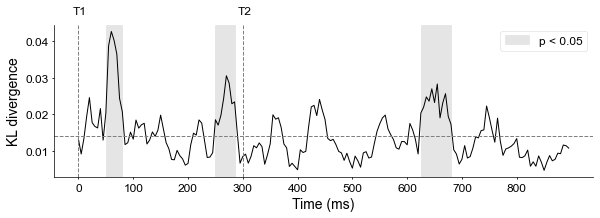

In [55]:
x_arr = np.arange(0,180,1)*5
pltSet.SetPlotDim(5*1.7, 2*1.6)
legend_size = 1

fig, ax = plt.subplots()
ax.spines[['right', 'top']].set_visible(False)
# plot_error_all(x_arr, baseline_y1,plot_title='',this_label='sem')
# plot_error_by_condition(x_arr,np.array(res_list),condition='', this_label='sem',base=None,is_group=True, ax=ax)
plt.plot(x_arr,np.array(res_list),linewidth=1,c='black')
ax.set_xticks(np.array([0,100,200,300,400,500,600,700,800]))
#ax.set_xticklabels([0,100,200,300,400,500,600,700,800]) 

idx=0
for order in range(3): #order=1
    m_precue = np.array(res_list)
    if pv_list_cluster[0][order][0]<0.05:
        # print(pv_list_cluster[roi]) 

        section_x = x_arr[pv_list_cluster[0][order][1][1]:pv_list_cluster[0][order][1][2] + 1]
        section_y = m_precue[pv_list_cluster[0][order][1][1]:pv_list_cluster[0][order][1][2] + 1]
        
        idx+=1
        if idx<3:
            plt.axvspan(section_x[0], section_x[-1],color='grey', alpha=0.2)
        else:
            plt.axvspan(section_x[0], section_x[-1],color='grey', alpha=0.2,label=r'p < 0.05')
        print(pv_list_cluster[0][order][0])

    # print("p-value after permutation:", pv_list_cluster[roi][0][0])

    #plt.scatter([(section_x[0]+section_x[-1])/2.0],[0.025], marker=(5, 2), s=24,color='black', label="p = %s" %pv_list_cluster[0][0])


# plt.axvline(x=data.time_window_T1_tmp[0] + data.pstart + data.time_ahead-1050, color='grey', linewidth=1,  ls='--')
plt.axvline(x=data.time_window_T2_tmp[0] + data.pstart + data.time_ahead-1050 , color='grey', linewidth=1, ls='--')
plt.axvline(x=data.time_window_T1_tmp[0] + data.pstart + data.time_ahead-1050, color='grey', linewidth=1,  ls='--')

anno_text_height=np.max(np.array(res_list))+ np.min(np.array(res_list))
plt.text(x=data.time_window_T1_tmp[0] + data.pstart + time_ahead-1050-10, y=anno_text_height, color='black', 
         fontsize=12*legend_size, s='T1')

plt.text(x=data.time_window_T2_tmp[0] + data.pstart + time_ahead-1050-10, y=anno_text_height, color='black', 
         fontsize=12*legend_size, s='T2')


plt.axhline(np.mean(np.array(res_list)),color='grey',linewidth=1, ls='--')
plt.xlabel("Time (ms)")
plt.ylabel("KL divergence")

plt.legend()

plot_str = 'T1KL_target_onset'

fig.savefig('/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/Result_DecodingNet/Manuscript_Figures/'
            '%s.svg' % plot_str, dpi=300)
# plt.title('Closeness centrality, T1 attend vs unattend', fontsize=14)

In [56]:
y1=np.array(T2at_rois_centrality_list)
y2=np.array(T2uat_rois_centrality_list)

In [76]:
st_t=9+60
ed_t=st_t+180
new_y1, new_y2 = y1[st_t:ed_t],y2[st_t:ed_t]

res_list=list()

for t in range(np.shape(new_y1)[0]):
    res_list.append(scipy.stats.entropy(new_y1[t,:],new_y2[t,:]))
    


In [77]:
pv_list_cluster = get_p_multi_subject_group_kl_test(new_y1, new_y2, 
                                           'paired t-test', order=-1, is_cluster=True, is_rd_cluster=True,
                                           thres=0.60,mc_size=1000,is_baseline=False,is_group_kl=True)

 13%|█▎        | 128/1000 [00:00<00:00, 1027.40it/s]

this_diff (180,)


 21%|██▏       | 213/1000 [00:00<00:00, 2123.77it/s]

mc_diff_list (1000, 180)
mc_diff_list (1000, 180)


100%|██████████| 1000/1000 [00:00<00:00, 2265.61it/s]


(180,)
[(8.23702222222222, 14, 23), (6.986427777777778, 5, 12), (6.2304611111111114, 90, 97), (5.7052000000000005, 173, 179), (4.473105555555556, 56, 60), (4.123205555555556, 37, 41), (2.81885, 138, 141), (2.7805722222222222, 82, 85), (2.1925499999999998, 121, 123), (2.0495555555555556, 47, 49), (1.9359555555555557, 0, 2), (1.4076777777777778, 73, 74), (1.400088888888889, 26, 27), (1.3105666666666667, 44, 45), (0.6504166666666666, 64, 64), (0.6006222222222222, 156, 156), (0, 0, 0)]
get obs_list
8.23702222222222 14 23
[6.19225556 6.20243889 6.21018333 6.22966667 6.24553889 6.26448889
 6.26826667 6.28869444 6.30598333 6.34433889 6.39183889 6.40686111
 6.42665    6.43531667 6.45642222 6.46899444 6.49023889 6.51173889
 6.51181667 6.56731111 6.63648889 6.63723889 6.65924444 6.68811667
 6.71736667 6.75907778 6.76153333 6.79640556 6.82301111 6.85770556
 6.86445556 6.87510556 6.93009444 7.03621667 7.14214444 7.16821667
 7.32763889 7.33618333 7.39791111 7.42455556 7.53847222 7.61896667
 7.62267

In [78]:
pv_list_cluster 

([(0.003, (8.23702222222222, 14, 23)),
  (0.017, (6.986427777777778, 5, 12)),
  (0.046, (6.2304611111111114, 90, 97)),
  (0.08, (5.7052000000000005, 173, 179)),
  (0.338, (4.473105555555556, 56, 60)),
  (0.458, (4.123205555555556, 37, 41)),
  (0.95, (2.81885, 138, 141)),
  (0.955, (2.7805722222222222, 82, 85)),
  (1.0, (2.1925499999999998, 121, 123)),
  (1.0, (2.0495555555555556, 47, 49)),
  (1.0, (1.9359555555555557, 0, 2)),
  (1.0, (1.4076777777777778, 73, 74)),
  (1.0, (1.400088888888889, 26, 27)),
  (1.0, (1.3105666666666667, 44, 45)),
  (1.0, (0.6504166666666666, 64, 64)),
  (1.0, (0.6006222222222222, 156, 156)),
  (1.0, (0, 0, 0))],
 14,
 23)

0.003
0.017
0.046


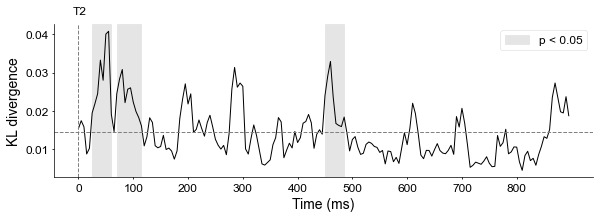

In [79]:
x_arr = np.arange(0,180,1)*5
pltSet.SetPlotDim(5*1.7, 2*1.6)
legend_size = 1

fig, ax = plt.subplots()
ax.spines[['right', 'top']].set_visible(False)
plt.plot(x_arr,np.array(res_list),linewidth=1, c='black')
ax.set_xticks(np.array([0,100,200,300,400,500,600,700,800]))

idx=0
for order in range(5): #order=1
    m_precue = np.array(res_list)
    idx+=1
    if pv_list_cluster[0][order][0]<0.05:
        # print(pv_list_cluster[roi]) 

        section_x = x_arr[pv_list_cluster[0][order][1][1]:pv_list_cluster[0][order][1][2] + 1]
        section_y = m_precue[pv_list_cluster[0][order][1][1]:pv_list_cluster[0][order][1][2] + 1]

        if idx<3:
            plt.axvspan(section_x[0], section_x[-1],color='grey', alpha=0.2)
        else:
            plt.axvspan(section_x[0], section_x[-1],color='grey', alpha=0.2,label=r'p < 0.05')
        print(pv_list_cluster[0][order][0])
    # print("p-value after permutation:", pv_list_cluster[roi][0][0])

    #plt.scatter([(section_x[0]+section_x[-1])/2.0],[0.025], marker=(5, 2), s=24,color='black', label="p = %s" %pv_list_cluster[0][0])


# plt.axvline(x=data.time_window_T1_tmp[0] + data.pstart + data.time_ahead-1050, color='grey', linewidth=1,  ls='--')
# plt.axvline(x=data.time_window_T2_tmp[0] + data.pstart + data.time_ahead-1050 , color='grey', linewidth=1, ls='--')
plt.axvline(x=data.time_window_T1_tmp[0] + data.pstart + data.time_ahead-1050, color='grey', linewidth=1,  ls='--')

plt.axhline(np.mean(np.array(res_list)),color='grey',linewidth=1, ls='--')

anno_text_height=np.max(np.array(res_list))+ np.min(np.array(res_list))
# plt.text(x=data.time_window_T1_tmp[0] + data.pstart + time_ahead-1050-10, y=anno_text_height, color='black', 
#          fontsize=12*legend_size, s='T1')

plt.text(x=data.time_window_T2_tmp[0] + data.pstart + time_ahead-1050-300-10, y=anno_text_height, color='black', 
         fontsize=12*legend_size, s='T2')

plt.xlabel("Time (ms)")
plt.ylabel("KL divergence")

plt.legend()

plot_str = 'T2KL_target_onset'

fig.savefig('/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/Result_DecodingNet/Manuscript_Figures/'
            '%s.svg' % plot_str, dpi=300)
# plt.title('Closeness centrality, T2 attend vs unattend', fontsize=12)